<a href="https://www.kaggle.com/code/sarraverse/train-b?scriptVersionId=307296839" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Cellule 1 — Installer les dépendances

In [1]:
!pip install transformers sentencepiece -q

# Cellule 2 — Setup et clone du repo

In [2]:
import os, sys

if not os.path.exists('/kaggle/working/sign-language-production'):
    os.system('git clone https://github.com/sarrazer24/sign-language-production.git /kaggle/working/sign-language-production')

data_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data'
print("Fichiers disponibles :", os.listdir(data_path))


Cloning into '/kaggle/working/sign-language-production'...


Fichiers disponibles : ['dataset.py', 'collate.py', 'normalize.py', 'stats.pt']


# Cellule 3 — Imports

In [3]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from transformers import T5EncoderModel, T5Tokenizer
import csv, json
from tqdm import tqdm

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_KP     = 151
POSE_DIM = N_KP * 3   # 453
BASE     = "/kaggle/input/datasets/sarraverse/how2signdataset"

print(f"Device : {DEVICE}")


Device : cuda


# Cellule 4 — Dataset et DataLoader

In [4]:
from transformers import T5Tokenizer

TOKENIZER_PATH = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_tokenizer'

class How2SignDataset(Dataset):
    def __init__(self, split='train', stats=None, max_frames=500):
        assert split in ['train', 'dev', 'test']
        self.max_frames  = max_frames
        self.n_keypoints = N_KP

        with open(f"{BASE}/{split}.skels", 'r') as f:
            self.skels_lines = f.readlines()
        with open(f"{BASE}/{split}.text", 'r', encoding='utf-8') as f:
            self.text_lines = f.readlines()
        with open(f"{BASE}/{split}.files", 'r') as f:
            self.files_lines = f.readlines()

        # Charger le tokenizer depuis le cache local si disponible,
        # sinon télécharger et sauvegarder pour les runs suivants
        if os.path.exists(TOKENIZER_PATH):
            self.tokenizer = T5Tokenizer.from_pretrained(TOKENIZER_PATH)
            print(f"✅ Tokenizer chargé depuis le cache local")
        else:
            print("⬇️  Téléchargement tokenizer T5...")
            self.tokenizer = T5Tokenizer.from_pretrained('t5-small')
            self.tokenizer.save_pretrained(TOKENIZER_PATH)
            print(f"✅ Tokenizer sauvegardé dans {TOKENIZER_PATH}")

        self.stats = stats

    def __len__(self):
        return len(self.skels_lines)

    def __getitem__(self, idx):
        vals     = np.array(self.skels_lines[idx].strip().split(), dtype=np.float32)
        n_frames = len(vals) // (self.n_keypoints * 3)
        poses    = vals[:n_frames * self.n_keypoints * 3].reshape(n_frames, self.n_keypoints, 3)

        if n_frames > self.max_frames:
            poses    = poses[:self.max_frames]
            n_frames = self.max_frames

        if self.stats is not None:
            mean = self.stats['mean'].numpy()
            std  = self.stats['std'].numpy()
            std  = np.where(std < 1e-6, 1.0, std)
            poses = (poses - mean) / std
            poses = np.clip(poses, -3.0, 3.0)

        poses = torch.FloatTensor(poses)
        text  = self.text_lines[idx].strip()
        enc   = self.tokenizer(
            text, return_tensors='pt',
            padding=False, truncation=True, max_length=200
        )
        return {
            'poses'         : poses,
            'pose_length'   : n_frames,
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'text'          : text,
            'file_ref'      : self.files_lines[idx].strip()
        }


def collate_fn(batch):
    batch        = sorted(batch, key=lambda x: x['pose_length'], reverse=True)
    pose_lengths = torch.LongTensor([item['pose_length'] for item in batch])
    T_max        = pose_lengths[0].item()
    B            = len(batch)
    K            = batch[0]['poses'].shape[1]

    poses_padded = torch.zeros(B, T_max, K, 3)
    pose_mask    = torch.zeros(B, T_max, dtype=torch.bool)
    for i, item in enumerate(batch):
        T = item['pose_length']
        poses_padded[i, :T] = item['poses']
        pose_mask[i, :T]    = True

    input_ids = torch.nn.utils.rnn.pad_sequence(
        [item['input_ids'] for item in batch],
        batch_first=True, padding_value=0
    )
    attention_mask = torch.nn.utils.rnn.pad_sequence(
        [item['attention_mask'] for item in batch],
        batch_first=True, padding_value=0
    )
    return {
        'poses'         : poses_padded,
        'pose_mask'     : pose_mask,
        'pose_lengths'  : pose_lengths,
        'input_ids'     : input_ids,
        'attention_mask': attention_mask,
        'texts'         : [item['text'] for item in batch]
    }


# Cellule 5 — Charger stats.pt et créer les DataLoaders

In [5]:
stats_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/stats.pt'

if os.path.exists(stats_path):
    stats = torch.load(stats_path)
    print("✅ stats.pt chargé depuis le repo")
else:
    print("⚠️ stats.pt introuvable — recalcul en cours...")
    all_poses = []
    with open(f"{BASE}/train.skels", 'r') as f:
        for i, line in enumerate(f):
            if i >= 5000: break
            vals     = np.array(line.strip().split(), dtype=np.float32)
            n_frames = len(vals) // (N_KP * 3)
            if n_frames == 0: continue
            poses = vals[:n_frames * N_KP * 3].reshape(n_frames, N_KP, 3)
            all_poses.append(poses[:100])
    all_poses = np.concatenate(all_poses, axis=0)
    stats = {
        'mean': torch.FloatTensor(all_poses.mean(axis=0)),
        'std' : torch.FloatTensor(all_poses.std(axis=0))
    }
    torch.save(stats, stats_path)
    print("✅ stats.pt recalculé et sauvegardé")

train_ds = How2SignDataset('train', stats=stats, max_frames=500)
dev_ds   = How2SignDataset('dev',   stats=stats, max_frames=500)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
dev_loader   = DataLoader(dev_ds,   batch_size=16, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

print(f"Train : {len(train_ds)} samples — {len(train_loader)} batches")
print(f"Dev   : {len(dev_ds)}   samples — {len(dev_loader)}   batches")

batch = next(iter(train_loader))
print(f"Batch poses shape : {batch['poses'].shape}")
print(f"Batch texte[0]    : {batch['texts'][0][:60]}")


✅ stats.pt chargé depuis le repo


⬇️  Téléchargement tokenizer T5...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer sauvegardé dans /kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_tokenizer
✅ Tokenizer chargé depuis le cache local
Train : 31046 samples — 1941 batches
Dev   : 1739   samples — 109   batches
Batch poses shape : torch.Size([16, 121, 151, 3])
Batch texte[0]    : We're going to take a small mixing bowl and we're going to g


# Cellule 6 — Bloc 1 : TextEncoder

In [6]:
T5_MODEL_PATH = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_model'

class TextEncoder(nn.Module):
    def __init__(self, model_name='t5-small', output_dim=512):
        super().__init__()
        if os.path.exists(T5_MODEL_PATH):
            self.encoder = T5EncoderModel.from_pretrained(T5_MODEL_PATH)
            print("✅ T5EncoderModel chargé depuis le cache local")
        else:
            print("⬇️  Téléchargement T5EncoderModel...")
            self.encoder = T5EncoderModel.from_pretrained(model_name)
            self.encoder.save_pretrained(T5_MODEL_PATH)
            print(f"✅ T5EncoderModel sauvegardé dans {T5_MODEL_PATH}")

        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.encoder.encoder.block[-2:].parameters():
            param.requires_grad = True

        hidden_size = self.encoder.config.d_model
        self.proj   = nn.Linear(hidden_size, output_dim) \
                      if hidden_size != output_dim else nn.Identity()

    def forward(self, input_ids, attention_mask):
        outputs       = self.encoder(input_ids=input_ids,
                                     attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state
        mask          = attention_mask.unsqueeze(-1).float()
        pooled        = (hidden_states * mask).sum(1) / mask.sum(1).clamp(1e-9)
        return self.proj(pooled)

# Cellule 7 — Bloc 2 : TimestepEmbedding

In [7]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def sinusoidal_embedding(self, timesteps):
        device = timesteps.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) *
            torch.arange(half, device=device) / (half - 1)
        )
        args = timesteps[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, timesteps):
        return self.mlp(self.sinusoidal_embedding(timesteps))  # (B, 512)


# Cellule 8 — Bloc 3 : SemanticTimestepConditioning (notre contribution)

In [8]:
class SemanticTimestepConditioning(nn.Module):
    def __init__(self, dim=512, num_heads=8):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, batch_first=True
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, t_embd, c_embd):
        t           = t_embd.unsqueeze(1)
        c           = c_embd.unsqueeze(1)
        attn_out, _ = self.cross_attn(query=t, key=c, value=c)
        t           = self.norm1(t + attn_out)
        t           = self.norm2(t + self.ffn(t))
        return t.squeeze(1)   # (B, 512)


# Cellule 9 — Bloc 4 : UNet1D

> **Amélioration :** `base_ch` augmenté à 128 (était 96) pour plus de capacité de modélisation
> et de meilleures poses générées.


In [9]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim=512):
        super().__init__()
        self.conv1     = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.conv2     = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.cond_proj = nn.Linear(cond_dim, out_ch * 2)
        self.norm1     = nn.GroupNorm(8, out_ch)
        self.norm2     = nn.GroupNorm(8, out_ch)
        self.act       = nn.SiLU()
        self.res_proj  = nn.Conv1d(in_ch, out_ch, 1) \
                         if in_ch != out_ch else nn.Identity()

    def forward(self, x, z_c):
        h            = self.act(self.norm1(self.conv1(x)))
        scale, shift = self.cond_proj(z_c).chunk(2, dim=-1)
        h            = h * (1 + scale.unsqueeze(-1)) + shift.unsqueeze(-1)
        h            = self.act(self.norm2(self.conv2(h)))
        return h + self.res_proj(x)


class UNet1D(nn.Module):
    def __init__(self, pose_dim=453, cond_dim=512, base_ch=128):
        super().__init__()
        C = base_ch
        self.input_proj  = nn.Conv1d(pose_dim, C, 1)
        self.enc1        = ResBlock1D(C,     C,     cond_dim)
        self.enc2        = ResBlock1D(C,     C * 2, cond_dim)
        self.enc3        = ResBlock1D(C * 2, C * 4, cond_dim)
        self.down1       = nn.Conv1d(C,     C,     3, stride=2, padding=1)
        self.down2       = nn.Conv1d(C * 2, C * 2, 3, stride=2, padding=1)
        self.down3       = nn.Conv1d(C * 4, C * 4, 3, stride=2, padding=1)
        self.bottleneck  = ResBlock1D(C * 4, C * 4, cond_dim)
        self.dec3        = ResBlock1D(C * 8, C * 4, cond_dim)
        self.dec2        = ResBlock1D(C * 6, C * 2, cond_dim)
        self.dec1        = ResBlock1D(C * 3, C,     cond_dim)
        self.up3         = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up2         = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up1         = nn.ConvTranspose1d(C * 2, C * 2, 4, stride=2, padding=1)
        self.output_proj = nn.Conv1d(C, pose_dim, 1)

    def _match_size(self, x, target):
        if x.shape[2] != target.shape[2]:
            x = x[:, :, :target.shape[2]]
        return x

    def forward(self, x, z_c):
        x  = self.input_proj(x.transpose(1, 2))
        s1 = self.enc1(x,  z_c);  x = self.down1(s1)
        s2 = self.enc2(x,  z_c);  x = self.down2(s2)
        s3 = self.enc3(x,  z_c);  x = self.down3(s3)
        x  = self.bottleneck(x, z_c)
        x  = self.dec3(torch.cat([self._match_size(self.up3(x), s3), s3], dim=1), z_c)
        x  = self.dec2(torch.cat([self._match_size(self.up2(x), s2), s2], dim=1), z_c)
        x  = self.dec1(torch.cat([self._match_size(self.up1(x), s1), s1], dim=1), z_c)
        return self.output_proj(x).transpose(1, 2)


# Cellule 10 — Bloc 5 : GaussianDiffusion

> **Amélioration :** `T=200` steps de diffusion au lieu de 100 — plus de granularité
> dans le débruitage → poses générées plus précises.
>
> **Fix maintenu :** `sample()` reçoit `z_c_fn(t_tensor)` pour recalculer le
> conditionneur STC au bon timestep à chaque step du reverse process.


In [10]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, T=200):
        super().__init__()
        self.model = model
        self.T     = T

        betas          = self._cosine_schedule(T)
        alphas         = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas',          betas)
        self.register_buffer('alphas',         alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('sqrt_acp',       torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus', torch.sqrt(1 - alphas_cumprod))

    def _cosine_schedule(self, T, s=0.008):
        steps = torch.arange(T + 1, dtype=torch.float32)
        f     = torch.cos((steps / T + s) / (1 + s) * math.pi / 2) ** 2
        betas = 1 - f[1:] / f[:-1]
        return torch.clamp(betas, 0.0001, 0.9999)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_acp[t][:, None, None]
        sm = self.sqrt_one_minus[t][:, None, None]
        return s * x0 + sm * noise, noise

    def compute_loss(self, x0, z_c, pose_mask):
        B          = x0.shape[0]
        t          = torch.randint(0, self.T, (B,), device=x0.device)
        x_t, noise = self.q_sample(x0, t)
        noise_pred = self.model(x_t, z_c)
        mask       = pose_mask.unsqueeze(-1).float()
        return ((noise_pred - noise) ** 2 * mask).sum() / mask.sum()

    @torch.no_grad()
    def p_sample(self, x_t, t_val, z_c):
        t        = torch.full((x_t.shape[0],), t_val,
                              device=x_t.device, dtype=torch.long)
        beta     = self.betas[t][:, None, None]
        alpha    = self.alphas[t][:, None, None]
        alpha_cp = self.alphas_cumprod[t][:, None, None]
        pred     = self.model(x_t, z_c)

        clip_val = 1.0 + 2.0 * (t_val / self.T)
        pred     = torch.clamp(pred, -clip_val, clip_val)

        coef = beta / torch.sqrt(1 - alpha_cp)
        mean = (1 / torch.sqrt(alpha)) * (x_t - coef * pred)
        mean = torch.clamp(mean, -3.0, 3.0)

        if t_val > 0:
            mean = mean + torch.sqrt(beta) * torch.randn_like(x_t)
        return mean

    @torch.no_grad()
    def sample(self, z_c_fn, n_frames, batch_size, device):
        """
        z_c_fn(t_tensor) -> z_c : recalcule le conditionneur STC à chaque step
        avec le bon timestep courant de la reverse diffusion.
        """
        x = torch.randn(batch_size, n_frames, POSE_DIM, device=device)
        for t_val in reversed(range(self.T)):
            t_tensor = torch.full((batch_size,), t_val, device=device, dtype=torch.long)
            z_c      = z_c_fn(t_tensor)
            x        = self.p_sample(x, t_val, z_c)
        return x


# Cellule 11 — Modèle complet ApproachB

In [11]:
class ApproachB(nn.Module):
    def __init__(self, T=200, use_contribution=True):
        super().__init__()
        self.use_contribution = use_contribution
        self.text_encoder     = TextEncoder()
        self.timestep_emb     = TimestepEmbedding(dim=512)
        self.semantic_cond    = SemanticTimestepConditioning(dim=512)
        self.unet             = UNet1D(pose_dim=POSE_DIM, base_ch=128)
        self.diffusion        = GaussianDiffusion(self.unet, T=T)
        self.naive_proj       = nn.Linear(512, 512)

    def get_condition(self, t_embd, c_embd):
        if self.use_contribution:
            return self.semantic_cond(t_embd, c_embd)
        else:
            return self.naive_proj(t_embd + c_embd)

    def forward(self, batch):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        poses          = batch['poses'].to(DEVICE)
        pose_mask      = batch['pose_mask'].to(DEVICE)

        B, T, K, _ = poses.shape
        x0         = poses.reshape(B, T, K * 3)           # (B, T, 453)

        c_embd = self.text_encoder(input_ids, attention_mask)  # (B, 512)
        t      = torch.randint(0, self.diffusion.T, (B,), device=DEVICE)
        t_embd = self.timestep_emb(t)
        z_c    = self.get_condition(t_embd, c_embd)

        return self.diffusion.compute_loss(x0, z_c, pose_mask)

    @torch.no_grad()
    def generate(self, input_ids, attention_mask, n_frames=55):
        self.eval()
        B      = input_ids.shape[0]
        c_embd = self.text_encoder(input_ids, attention_mask)

        def z_c_fn(t_tensor):
            t_embd = self.timestep_emb(t_tensor)
            return self.get_condition(t_embd, c_embd)

        poses = self.diffusion.sample(z_c_fn, n_frames, batch_size=B, device=DEVICE)
        return poses.reshape(B, n_frames, N_KP, 3)


# ── Test forward pass ─────────────────────────────────────────────
model_test = ApproachB(T=200, use_contribution=True).to(DEVICE)
batch_test = next(iter(train_loader))
loss_test  = model_test(batch_test)
print(f"✅ Forward pass OK — Loss test : {loss_test.item():.4f}")
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {total_params:,}")
del model_test


⬇️  Téléchargement T5EncoderModel...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ T5EncoderModel sauvegardé dans /kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_model
✅ Forward pass OK — Loss test : 555.3996
Paramètres entraînables : 23,020,613


# Cellule 12 — Fonctions d'entraînement et d'évaluation

In [12]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss = model(batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for batch in tqdm(loader, desc="Eval", leave=False):
        with torch.cuda.amp.autocast():
            loss = model(batch)
        total_loss += loss.item()
    return total_loss / len(loader)


# Cellule 13 — Lancement entraînement

> **Changements :**
> - **Pas d'early stopping** — on entraîne jusqu'à `n_epochs_max` pour laisser
>   le modèle converger pleinement, utile pour les modèles de diffusion qui
>   améliorent souvent les metrics tardivement.
> - **200 epochs** au lieu de 150.
> - **Checkpoint toutes les 10 epochs** en plus du meilleur checkpoint,
>   pour pouvoir comparer l'évolution.
> - **LR = 1e-4** légèrement plus élevé pour converger plus vite sur 200 epochs.


In [13]:
def run_training(use_contribution=True, n_epochs=120, lr=1e-4, tag="with_contrib"):
    model     = ApproachB(T=200, use_contribution=use_contribution).to(DEVICE)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-2
    )
    # CosineAnnealingWarmRestarts : relance le LR toutes les 50 epochs
    # aide à sortir des minima locaux sur un long entraînement
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=1, eta_min=1e-6
    )
    scaler        = torch.cuda.amp.GradScaler()
    history       = {'train': [], 'dev': []}
    best_dev_loss = float('inf')

    print(f"\n{'='*60}")
    print(f"Entraînement — {tag}")
    print(f"Epochs : {n_epochs} | LR : {lr} | T_diffusion : 200 | base_ch : 128")
    print(f"Early stopping : DÉSACTIVÉ")
    print(f"Paramètres entraînables : "
          f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*60}\n")

    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        dev_loss   = evaluate(model, dev_loader)
        scheduler.step(epoch)

        history['train'].append(train_loss)
        history['dev'].append(dev_loss)

        # Sauvegarder le meilleur checkpoint
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            torch.save(model.state_dict(), f'/kaggle/working/best_{tag}.pt')
            marker = "✅ Nouveau meilleur"
        else:
            marker = ""

        # Checkpoint périodique toutes les 10 epochs
        if epoch % 10 == 0:
            torch.save(model.state_dict(),
                       f'/kaggle/working/checkpoint_{tag}_ep{epoch:03d}.pt')

        print(f"Epoch {epoch:3d}/{n_epochs} | "
              f"Train: {train_loss:.4f} | Dev: {dev_loss:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.2e}  {marker}")

    print(f"\n{'='*60}")
    print(f"Entraînement terminé — {n_epochs} epochs")
    print(f"Meilleure dev loss : {best_dev_loss:.4f}")
    print(f"{'='*60}\n")

    # Charger le meilleur checkpoint pour l'évaluation
    model.load_state_dict(
        torch.load(f'/kaggle/working/best_{tag}.pt', map_location=DEVICE)
    )
    return model, history


model_with,    history_with    = run_training(use_contribution=True,
                                               n_epochs=120,
                                               lr=1e-4,
                                               tag="with_contrib")

model_without, history_without = run_training(use_contribution=False,
                                               n_epochs=120,
                                               lr=1e-4,
                                               tag="without_contrib")


Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

✅ T5EncoderModel chargé depuis le cache local


/tmp/ipykernel_24/3347497908.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler        = torch.cuda.amp.GradScaler()



Entraînement — with_contrib
Epochs : 120 | LR : 0.0001 | T_diffusion : 200 | base_ch : 128
Early stopping : DÉSACTIVÉ
Paramètres entraînables : 23,020,613



Train:   0%|          | 0/1941 [00:00<?, ?it/s]/tmp/ipykernel_24/4046232825.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval:   0%|          | 0/109 [00:00<?, ?it/s]/tmp/ipykernel_24/4046232825.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 116/120 | Train: 327.4125 | Dev: 328.2440 | LR: 7.70e-05  


Epoch 117/120 | Train: 327.3254 | Dev: 327.5751 | LR: 7.43e-05  


Epoch 118/120 | Train: 327.3823 | Dev: 327.5761 | LR: 7.16e-05  


Epoch 119/120 | Train: 327.3670 | Dev: 327.4566 | LR: 6.87e-05  


Epoch 120/120 | Train: 327.3659 | Dev: 327.6297 | LR: 6.58e-05  

Entraînement terminé — 120 epochs
Meilleure dev loss : 327.3068



# Cellule 14 — Courbes de convergence (log scale)

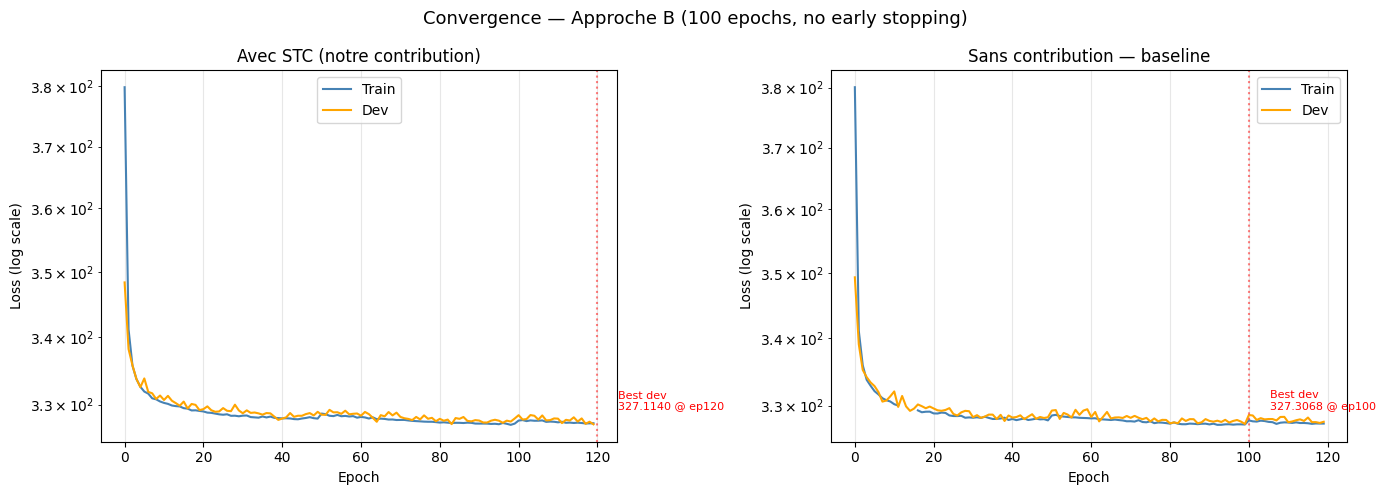

Meilleure dev loss AVEC : 327.1140  @ epoch 120
Meilleure dev loss SANS : 327.3068  @ epoch 100


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title in [
    (axes[0], history_with,    'Avec STC (notre contribution)'),
    (axes[1], history_without, 'Sans contribution — baseline')
]:
    ax.plot(hist['train'], label='Train', color='steelblue', linewidth=1.5)
    ax.plot(hist['dev'],   label='Dev',   color='orange',    linewidth=1.5)
    ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (log scale)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    best_ep = int(np.argmin(hist['dev'])) + 1
    best_v  = min(hist['dev'])
    ax.axvline(best_ep, color='red', linestyle=':', alpha=0.5)
    ax.annotate(f"Best dev\n{best_v:.4f} @ ep{best_ep}",
                xy=(best_ep, best_v), xytext=(15, 10),
                textcoords='offset points', fontsize=8, color='red')

plt.suptitle('Convergence — Approche B (100 epochs, no early stopping)', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/convergence_approach_b.png', dpi=150)
plt.show()

print(f"Meilleure dev loss AVEC : {min(history_with['dev']):.4f}  "
      f"@ epoch {np.argmin(history_with['dev'])+1}")
print(f"Meilleure dev loss SANS : {min(history_without['dev']):.4f}  "
      f"@ epoch {np.argmin(history_without['dev'])+1}")


# Cellule 15 — Courbes de loss comparatives

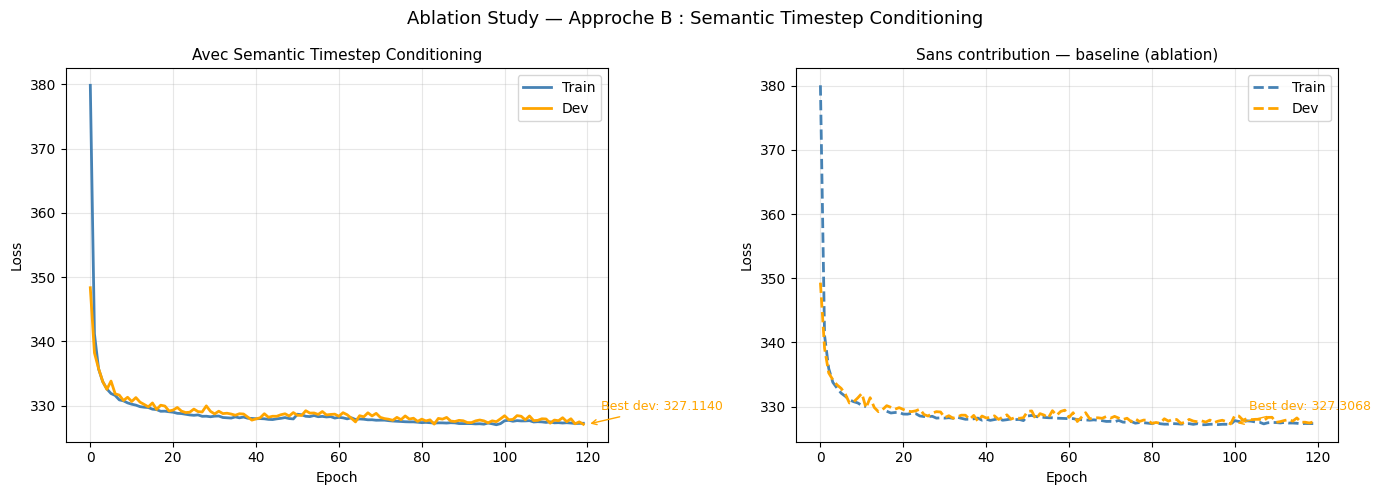

Meilleure dev loss AVEC : 327.1140
Meilleure dev loss SANS : 327.3068
Gain de notre contribution : +0.1928


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_with['train'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(history_with['dev'],   label='Dev',   color='orange',    linewidth=2)
axes[0].set_title('Avec Semantic Timestep Conditioning', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].annotate(f"Best dev: {min(history_with['dev']):.4f}",
                 xy=(np.argmin(history_with['dev'])+1, min(history_with['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

axes[1].plot(history_without['train'], label='Train', color='steelblue',
             linewidth=2, linestyle='--')
axes[1].plot(history_without['dev'],   label='Dev',   color='orange',
             linewidth=2, linestyle='--')
axes[1].set_title('Sans contribution — baseline (ablation)', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].annotate(f"Best dev: {min(history_without['dev']):.4f}",
                 xy=(np.argmin(history_without['dev'])+1, min(history_without['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

plt.suptitle('Ablation Study — Approche B : Semantic Timestep Conditioning', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves_approach_b.png', dpi=150)
plt.show()

gain = min(history_without['dev']) - min(history_with['dev'])
print(f"Meilleure dev loss AVEC : {min(history_with['dev']):.4f}")
print(f"Meilleure dev loss SANS : {min(history_without['dev']):.4f}")
print(f"Gain de notre contribution : {gain:+.4f}")


# Cellule 16 — Vérification des plages de valeurs

In [16]:
batch = next(iter(dev_loader))
gt    = batch['poses']

input_ids      = batch['input_ids'].to(DEVICE)
attention_mask = batch['attention_mask'].to(DEVICE)
n_frames       = int(batch['pose_lengths'].float().mean().item())

with torch.no_grad():
    pred = model_with.generate(input_ids, attention_mask, n_frames=n_frames)

print("Espace normalisé :")
print(f"  GT    — min: {gt.min():.4f}, max: {gt.max():.4f}, mean: {gt.mean():.4f}")
print(f"  Pred  — min: {pred.min():.4f}, max: {pred.max():.4f}, mean: {pred.mean():.4f}")

mean_np     = stats['mean'].numpy()
std_np      = stats['std'].numpy()
gt_denorm   = gt.numpy()   * std_np + mean_np
pred_denorm = pred.cpu().numpy() * std_np + mean_np

print("\nEspace original (dénormalisé) :")
print(f"  GT    — min: {gt_denorm.min():.4f}, max: {gt_denorm.max():.4f}")
print(f"  Pred  — min: {pred_denorm.min():.4f}, max: {pred_denorm.max():.4f}")


Espace normalisé :
  GT    — min: -3.0000, max: 3.0000, mean: 0.0031
  Pred  — min: -3.0000, max: 3.0000, mean: 0.0052

Espace original (dénormalisé) :
  GT    — min: -0.3301, max: 1.0000
  Pred  — min: -0.3832, max: 1.3098


# Cellule 17 — MPJPE (dénormalisé, par séquence)

In [17]:
@torch.no_grad()
def compute_mpjpe(model, loader, stats, n_samples=200):
    """
    MPJPE en espace dénormalisé.
    Génère chaque séquence avec sa vraie longueur individuelle.
    """
    model.eval()
    mean_t = stats['mean'].to(DEVICE)   # (151, 3)
    std_t  = stats['std'].to(DEVICE)    # (151, 3)
    scores = []
    count  = 0

    for batch in tqdm(loader, desc="MPJPE", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)
        pose_lengths   = batch['pose_lengths']
        B              = gt_poses.shape[0]

        for i in range(B):
            L           = pose_lengths[i].item()
            pred_i      = model.generate(input_ids[i:i+1],
                                         attention_mask[i:i+1],
                                         n_frames=L)           # (1, L, 151, 3)
            gt_i        = gt_poses[i, :L]
            gt_denorm   = gt_i     * std_t + mean_t
            pred_denorm = pred_i[0] * std_t + mean_t
            dist        = torch.norm(pred_denorm - gt_denorm, dim=-1)  # (L, 151)
            scores.append(dist.mean().item())

        count += B
        if count >= n_samples:
            break

    return float(np.mean(scores))


# Cellule 18 — DTW (Dynamic Time Warping)

> DTW mesure la similarité temporelle entre deux séquences de longueurs différentes.
> Contrairement à MPJPE (qui compare frame-à-frame), DTW trouve l'alignement optimal
> entre les trajectoires prédite et GT, ce qui est plus adapté aux séquences de gestes
> où les vitesses d'exécution peuvent varier.
>
> **Implémentation :** DTW vectorisé sur les 151 keypoints, calculé en espace dénormalisé.
> On utilise la distance euclidienne entre poses complètes comme coût de distorsion.


In [18]:
def dtw_distance(seq1, seq2):
    """
    DTW entre deux séquences de poses.
    seq1 : (T1, 151, 3) — numpy, espace dénormalisé
    seq2 : (T2, 151, 3) — numpy, espace dénormalisé
    Retourne le coût DTW normalisé par (T1 + T2).
    """
    T1, T2 = len(seq1), len(seq2)

    # Aplatir les poses : (T, 151*3)
    s1 = seq1.reshape(T1, -1).astype(np.float32)
    s2 = seq2.reshape(T2, -1).astype(np.float32)

    # Matrice de coût : distance euclidienne entre chaque paire de frames
    # Vectorisé : évite la double boucle Python
    diff = s1[:, None, :] - s2[None, :, :]          # (T1, T2, D)
    cost = np.sqrt((diff ** 2).sum(axis=-1))         # (T1, T2)

    # Programmation dynamique DTW
    dtw = np.full((T1 + 1, T2 + 1), np.inf, dtype=np.float32)
    dtw[0, 0] = 0.0
    for i in range(1, T1 + 1):
        for j in range(1, T2 + 1):
            dtw[i, j] = cost[i-1, j-1] + min(
                dtw[i-1, j],    # insertion
                dtw[i, j-1],    # deletion
                dtw[i-1, j-1]   # match
            )

    # Normaliser par la longueur du chemin optimal
    return float(dtw[T1, T2]) / (T1 + T2)


@torch.no_grad()
def compute_dtw(model, loader, stats, n_samples=100):
    """
    DTW moyen sur n_samples séquences du loader.
    Moins de samples que MPJPE car DTW est O(T1*T2) en temps.
    """
    model.eval()
    mean_np = stats['mean'].numpy()   # (151, 3)
    std_np  = stats['std'].numpy()    # (151, 3)
    mean_t  = stats['mean'].to(DEVICE)
    std_t   = stats['std'].to(DEVICE)

    scores = []
    count  = 0

    for batch in tqdm(loader, desc="DTW", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)
        pose_lengths   = batch['pose_lengths']
        B              = gt_poses.shape[0]

        for i in range(B):
            L = pose_lengths[i].item()

            # Générer la séquence prédite
            pred_i = model.generate(input_ids[i:i+1],
                                    attention_mask[i:i+1],
                                    n_frames=L)            # (1, L, 151, 3) normalisé

            # Dénormaliser
            gt_denorm   = (gt_poses[i, :L]  * std_t + mean_t).cpu().numpy()  # (L, 151, 3)
            pred_denorm = (pred_i[0]         * std_t + mean_t).cpu().numpy()  # (L, 151, 3)

            dtw_score = dtw_distance(pred_denorm, gt_denorm)
            scores.append(dtw_score)

        count += B
        if count >= n_samples:
            break

    return float(np.mean(scores))


# Cellule 19 — Calcul des métriques (MPJPE + DTW)

In [19]:
print("Calcul MPJPE...")
mpjpe_with    = compute_mpjpe(model_with,    dev_loader, stats, n_samples=200)
mpjpe_without = compute_mpjpe(model_without, dev_loader, stats, n_samples=200)

print("\nCalcul DTW (plus lent — O(T²) par séquence)...")
dtw_with    = compute_dtw(model_with,    dev_loader, stats, n_samples=100)
dtw_without = compute_dtw(model_without, dev_loader, stats, n_samples=100)

print(f"\n{'='*55}")
print(f"{'Métrique':<20} {'AVEC STC':>12} {'SANS STC':>12} {'Gain':>10}")
print(f"{'-'*55}")
print(f"{'MPJPE ↓':<20} {mpjpe_with:>12.4f} {mpjpe_without:>12.4f} "
      f"{mpjpe_without - mpjpe_with:>+10.4f}")
print(f"{'DTW ↓':<20} {dtw_with:>12.4f} {dtw_without:>12.4f} "
      f"{dtw_without - dtw_with:>+10.4f}")
print(f"{'='*55}")
print("↓ = plus bas est mieux | Gain positif = STC aide")


Calcul MPJPE...



Calcul DTW (plus lent — O(T²) par séquence)...



Métrique                 AVEC STC     SANS STC       Gain
-------------------------------------------------------
MPJPE ↓                    0.2218       0.2217    -0.0001
DTW ↓                      1.5002       1.4951    -0.0051
↓ = plus bas est mieux | Gain positif = STC aide


# Cellule 20 — Visualisation des métriques

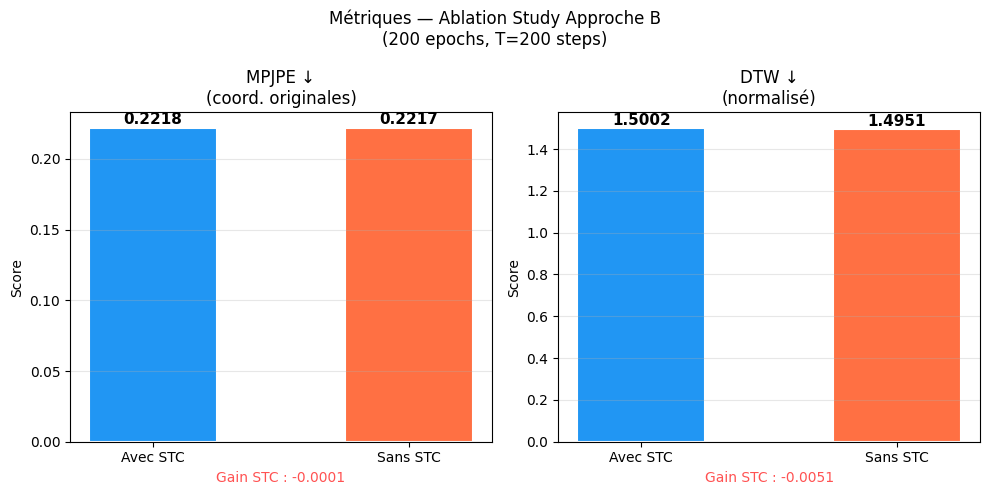

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

metrics = {
    'MPJPE ↓\n(coord. originales)': (mpjpe_with, mpjpe_without),
    'DTW ↓\n(normalisé)':           (dtw_with,   dtw_without),
}

for ax, (metric_name, (val_with, val_without)) in zip(axes, metrics.items()):
    bars = ax.bar(['Avec STC', 'Sans STC'],
                  [val_with, val_without],
                  color=['#2196F3', '#FF7043'],
                  width=0.5, edgecolor='white', linewidth=1.5)
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, [val_with, val_without]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    gain = val_without - val_with
    color = '#4CAF50' if gain > 0 else '#FF5252'
    ax.set_xlabel(f"Gain STC : {gain:+.4f}", color=color, fontsize=10)

plt.suptitle('Métriques — Ablation Study Approche B\n(200 epochs, T=200 steps)',
             fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/metrics_approach_b.png', dpi=150)
plt.show()


# Cellule 21 — Visualisation squelettes connectés

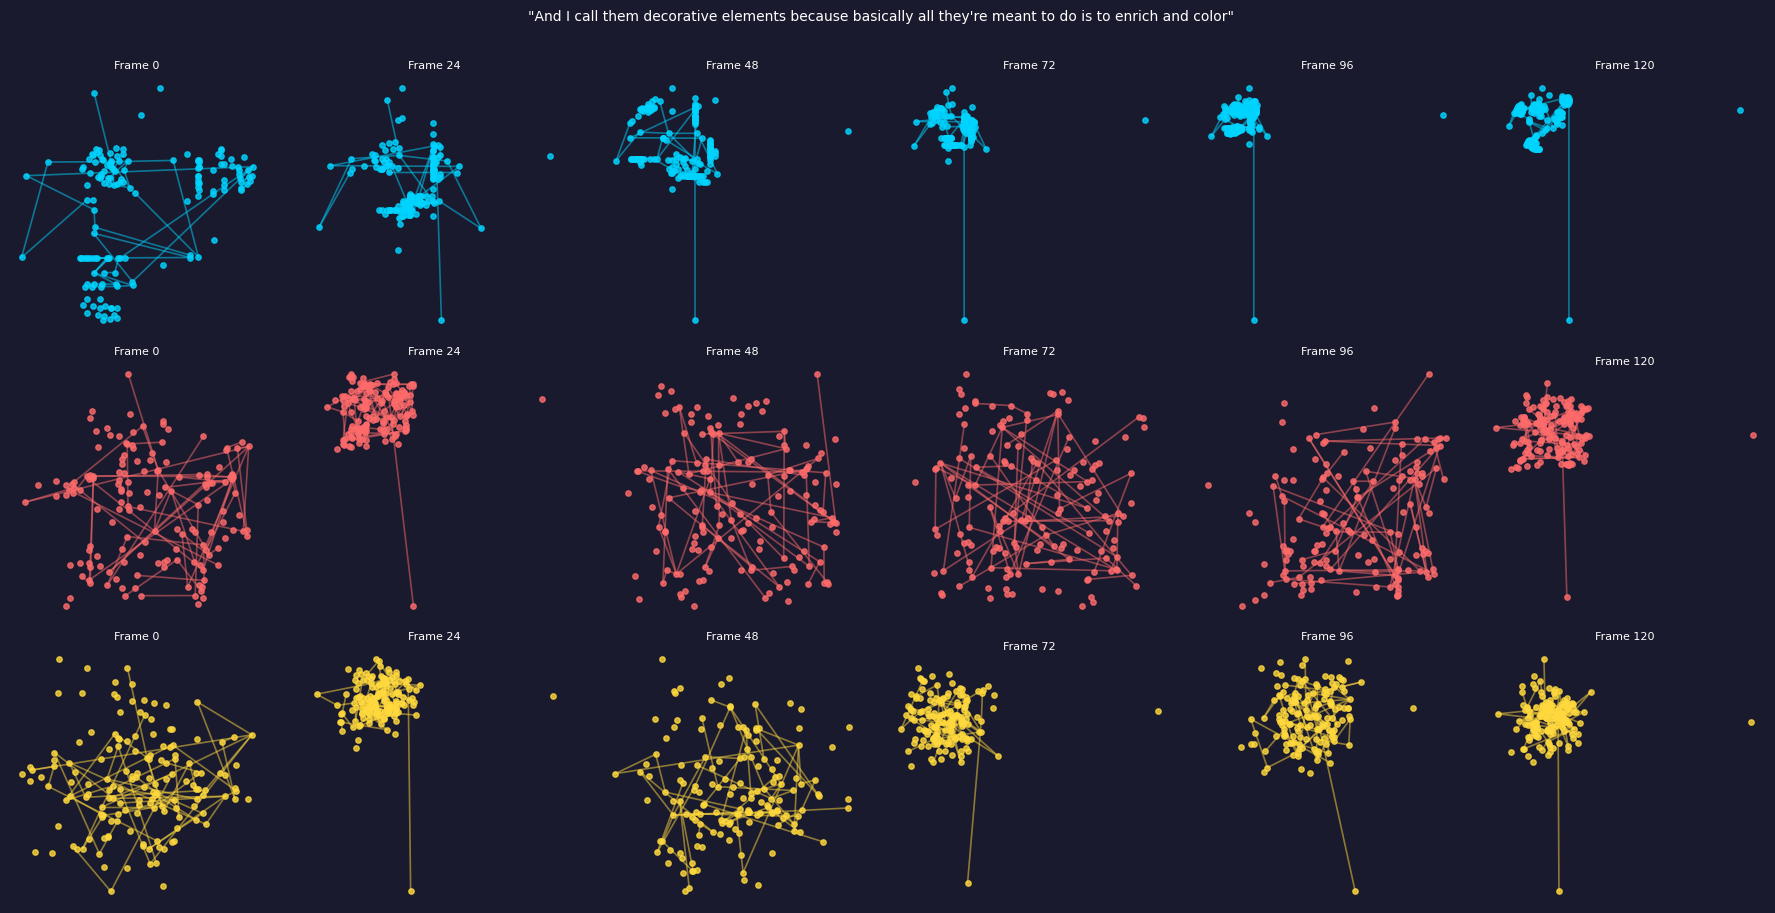

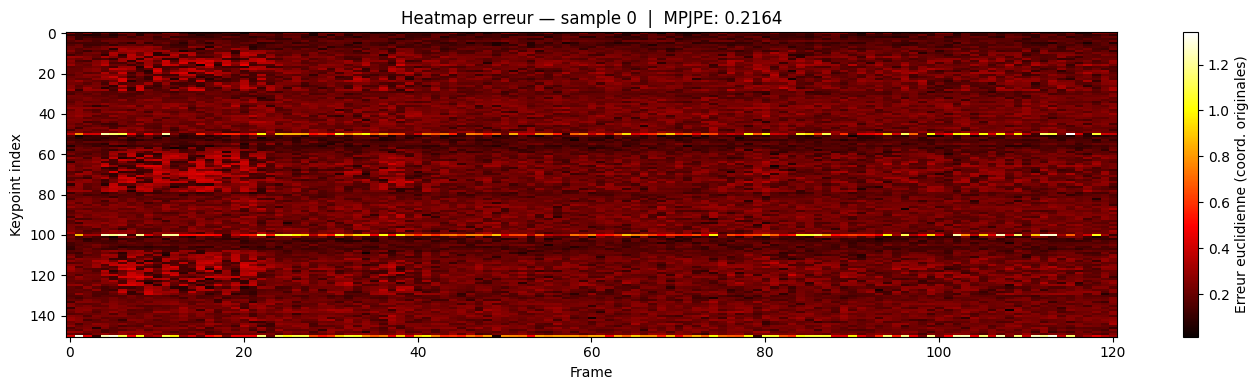

Séquence : 121 frames | MPJPE: 0.2164 | Keypoint le plus erroné : #150 (0.7242)


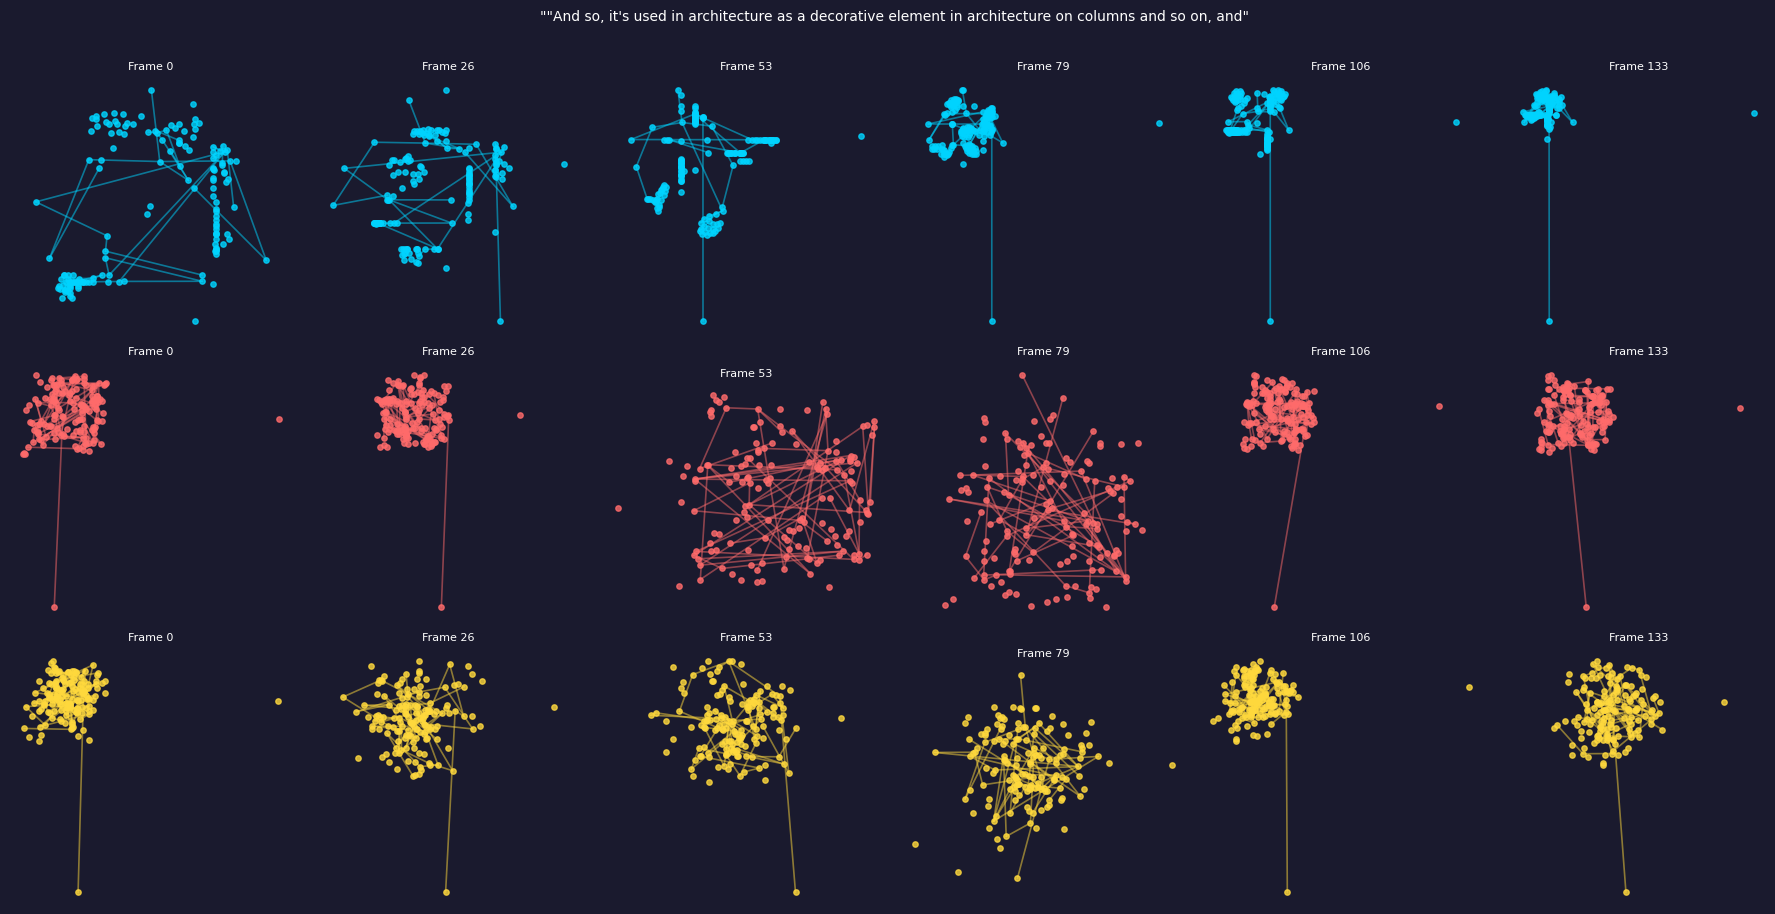

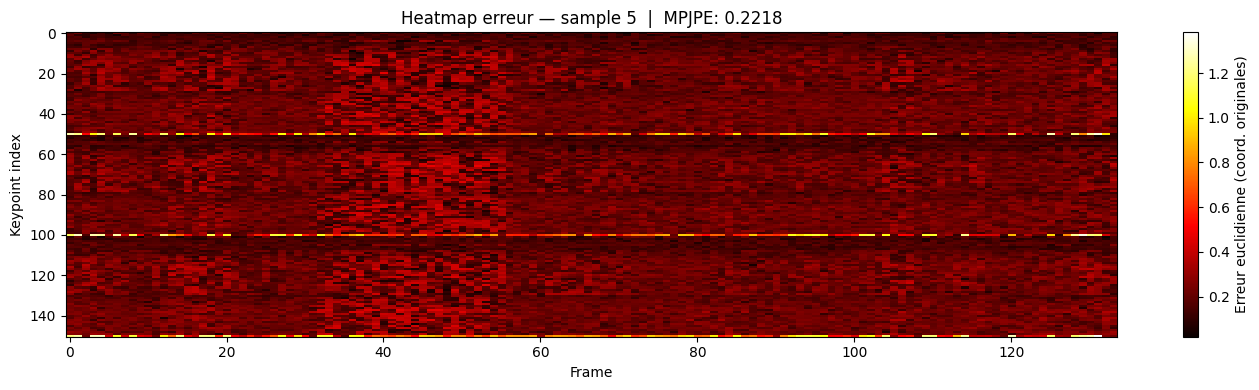

Séquence : 134 frames | MPJPE: 0.2218 | Keypoint le plus erroné : #150 (0.7392)


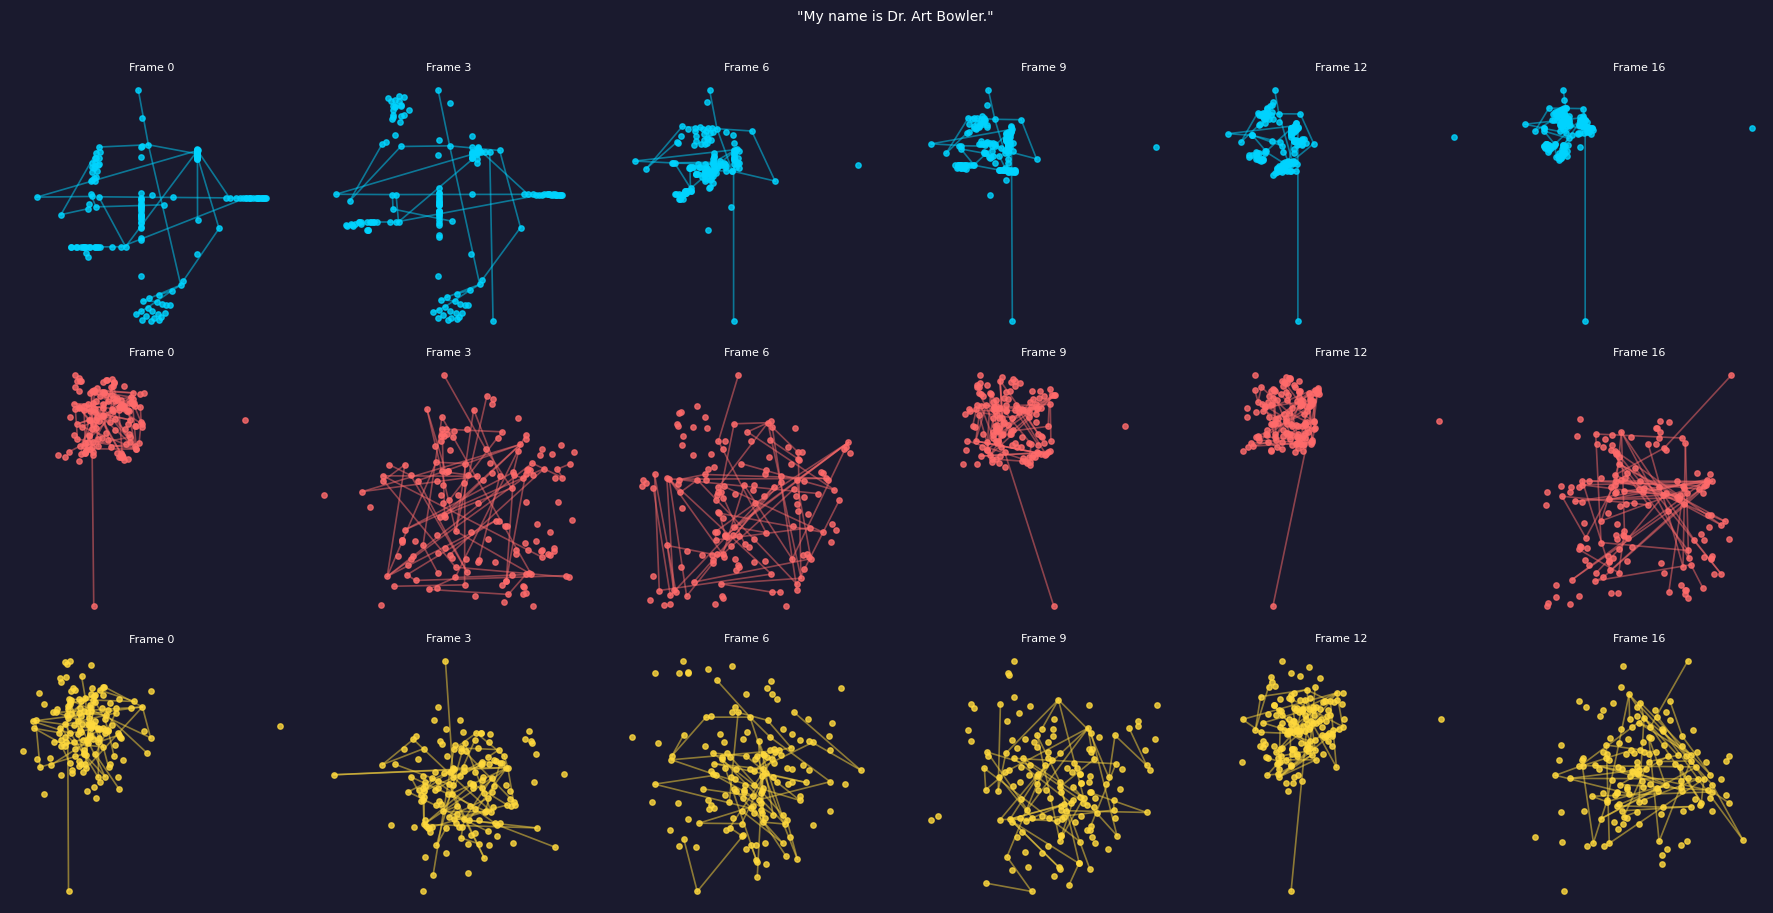

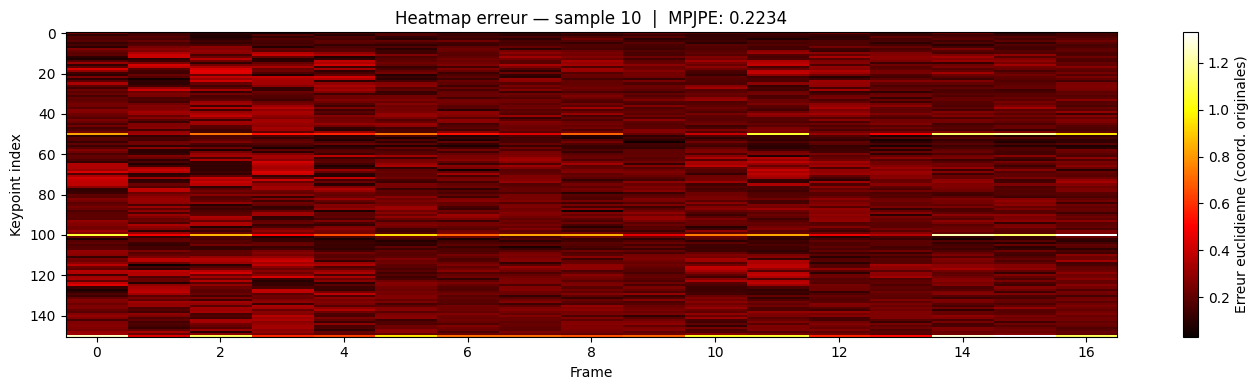

Séquence : 17 frames | MPJPE: 0.2234 | Keypoint le plus erroné : #150 (0.8647)


In [21]:
from scipy.ndimage import gaussian_filter1d

BODY_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (1, 5), (5, 6), (6, 7),
    (1, 8), (8, 9), (9, 10),
    (8, 11), (11, 12), (12, 13),
    (9, 14), (14, 15), (15, 16),
    (92, 93), (93, 94), (94, 95), (95, 96),
    (92, 97), (97, 98), (98, 99), (99, 100),
    (92, 101), (101, 102), (102, 103), (103, 104),
    (92, 105), (105, 106), (106, 107), (107, 108),
    (92, 109), (109, 110), (110, 111), (111, 112),
    (113, 114), (114, 115), (115, 116), (116, 117),
    (113, 118), (118, 119), (119, 120), (120, 121),
    (113, 122), (122, 123), (123, 124), (124, 125),
    (113, 126), (126, 127), (127, 128), (128, 129),
    (113, 130), (130, 131), (131, 132), (132, 133),
]

def smooth_poses(poses, sigma=1.5):
    smoothed = np.copy(poses)
    for kp in range(poses.shape[1]):
        for coord in range(poses.shape[2]):
            smoothed[:, kp, coord] = gaussian_filter1d(poses[:, kp, coord], sigma=sigma)
    return smoothed

def plot_skeleton_connected(ax, frame, color='steelblue', alpha=0.8):
    ax.scatter(frame[:, 0], -frame[:, 1], s=15, c=color, alpha=alpha, zorder=3)
    for (i, j) in BODY_CONNECTIONS:
        if i < len(frame) and j < len(frame):
            ax.plot([frame[i, 0], frame[j, 0]], [-frame[i, 1], -frame[j, 1]],
                    c=color, alpha=0.5, linewidth=1.2, zorder=2)
    ax.axis('off'); ax.set_aspect('equal')

@torch.no_grad()
def visualize_full(model, dataset, stats, idx=0):
    model.eval()
    mean_np = stats['mean'].numpy()
    std_np  = stats['std'].numpy()

    sample         = dataset[idx]
    input_ids      = sample['input_ids'].unsqueeze(0).to(DEVICE)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(DEVICE)
    gt_norm        = sample['poses'].numpy()
    text           = sample['text']
    n_frames       = gt_norm.shape[0]

    pred_norm     = model.generate(input_ids, attention_mask,
                                   n_frames=n_frames)[0].cpu().numpy()

    gt_poses      = gt_norm   * std_np + mean_np
    pred_poses    = pred_norm * std_np + mean_np
    pred_smoothed = smooth_poses(pred_poses, sigma=1.5)

    n_show  = 6
    indices = np.linspace(0, min(len(gt_poses), len(pred_poses)) - 1, n_show, dtype=int)

    fig, axes = plt.subplots(3, n_show, figsize=(18, 9), facecolor='#1a1a2e')
    fig.suptitle(f'\"{text[:100]}\"', fontsize=10, color='white', y=1.01)

    for col, fi in enumerate(indices):
        for row, (poses, color, label) in enumerate([
            (gt_poses,      '#00d4ff', 'Ground Truth'),
            (pred_poses,    '#ff6b6b', 'Généré (brut)'),
            (pred_smoothed, '#ffd93d', 'Généré (lissé)')
        ]):
            axes[row, col].set_facecolor('#1a1a2e')
            plot_skeleton_connected(axes[row, col], poses[fi], color=color)
            axes[row, col].set_title(f'Frame {fi}', fontsize=8, color='white')
            if col == 0:
                axes[row, col].set_ylabel(label, fontsize=10,
                                           color=color, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/viz_full_{idx}.png',
                dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()

    # Heatmap erreur
    min_T  = min(len(gt_poses), len(pred_poses))
    errors = np.linalg.norm(pred_poses[:min_T] - gt_poses[:min_T], axis=-1)
    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(errors.T, aspect='auto', cmap='hot', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Erreur euclidienne (coord. originales)')
    ax.set_xlabel('Frame'); ax.set_ylabel('Keypoint index')
    ax.set_title(f'Heatmap erreur — sample {idx}  |  MPJPE: {errors.mean():.4f}')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/heatmap_{idx}.png', dpi=150)
    plt.show()

    print(f"Séquence : {n_frames} frames | MPJPE: {errors.mean():.4f} | "
          f"Keypoint le plus erroné : #{errors.mean(axis=0).argmax()} "
          f"({errors.mean(axis=0).max():.4f})")


for idx in [0, 5, 10]:
    visualize_full(model_with, train_ds, stats, idx=idx)


# Cellule 22 — Sauvegarder résultats et push

In [22]:
import os

output_dir = '/kaggle/working/outputs_approach_b'
os.makedirs(output_dir, exist_ok=True)

torch.save(model_with.state_dict(),
           f'{output_dir}/model_with_contribution.pt')
torch.save(model_without.state_dict(),
           f'{output_dir}/model_without_contribution.pt')
print("✅ Checkpoints sauvegardés")

with open(f'{output_dir}/history_with.json', 'w') as f:
    json.dump(history_with, f)
with open(f'{output_dir}/history_without.json', 'w') as f:
    json.dump(history_without, f)
print("✅ Historiques de loss sauvegardés")

results_path = f'{output_dir}/results_approach_b.csv'
rows = [
    {
        'approach'       : 'B_with_contribution',
        'description'    : 'DDPM + STC (T=200, 200 epochs, base_ch=128)',
        'best_train_loss': round(min(history_with['train']),    4),
        'best_dev_loss'  : round(min(history_with['dev']),      4),
        'mpjpe_dev'      : round(mpjpe_with,                    4),
        'dtw_dev'        : round(dtw_with,                      4),
        'best_epoch'     : int(np.argmin(history_with['dev']) + 1),
    },
    {
        'approach'       : 'B_without_contribution',
        'description'    : 'DDPM baseline ablation (T=200, 200 epochs, base_ch=128)',
        'best_train_loss': round(min(history_without['train']), 4),
        'best_dev_loss'  : round(min(history_without['dev']),   4),
        'mpjpe_dev'      : round(mpjpe_without,                 4),
        'dtw_dev'        : round(dtw_without,                   4),
        'best_epoch'     : int(np.argmin(history_without['dev']) + 1),
    }
]
with open(results_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print("✅ results_approach_b.csv sauvegardé")

print(f"\n{'='*55}")
print(f"Résultats finaux :")
print(f"  MPJPE AVEC STC : {mpjpe_with:.4f}")
print(f"  MPJPE SANS STC : {mpjpe_without:.4f}")
print(f"  DTW   AVEC STC : {dtw_with:.4f}")
print(f"  DTW   SANS STC : {dtw_without:.4f}")
print(f"{'='*55}")

print(f"\nFichiers dans {output_dir}:")
for fname in sorted(os.listdir(output_dir)):
    size = os.path.getsize(f'{output_dir}/{fname}') / 1024
    print(f"  {fname:50s} {size:8.1f} KB")


✅ Checkpoints sauvegardés
✅ Historiques de loss sauvegardés
✅ results_approach_b.csv sauvegardé

Résultats finaux :
  MPJPE AVEC STC : 0.2218
  MPJPE SANS STC : 0.2217
  DTW   AVEC STC : 1.5002
  DTW   SANS STC : 1.4951

Fichiers dans /kaggle/working/outputs_approach_b:
  history_with.json                                       4.6 KB
  history_without.json                                    4.5 KB
  model_with_contribution.pt                         203439.8 KB
  model_without_contribution.pt                      203440.3 KB
  results_approach_b.csv                                  0.3 KB
